In [1]:
import numpy as np
import pickle

# Parallel computation
from joblib import Parallel, delayed

# Import methods and simulation function
from method import *
from tools.simul import simul_uniform_mixture, run_parallel_method
import os

# Clean up the output
np.set_printoptions(precision=3, suppress=True)

# Set the random seed for reproducibility
SEED = 20241225

# Number of Monte Carlo replications for each setting
reps = 100

# Number of parallel jobs for running replications (adjust this based on your machine capabilities)
njobs = min(100, os.cpu_count())

# Reproducing the Simulation Experiments
All functions generating simulated data are included in `simul.py`.  

To run codes, create directories `./results/simulation/` (for Setting 1) and `./results/simulation2/` (for Setting 2) to save the simulation results.

*Computing Device (Multi-Core Cluster) Information*
- OS: Rocky Linux 9.3
- CPU: Intel Xeon Gold 6348 2.60 GHz
- `Python == 3.11.8`
- `numpy == 1.26.4`, `pandas == 2.2.2`, `scipy == 1.13.0`

## Setting 1

In [2]:
noise_levels = [0, 5, 10]
loss_types = ["Loss1", "Loss2"]
n = 200
K = {"de": 3, "sa": 2, "ss": 3, "paa": 3}
# K=2 is used for SA to get more results.

##### Differential Evolution (DE)

In [ ]:
# 33min with 100 cores
for noise in noise_levels:
    for loss in loss_types:
        rep100_result = run_parallel_method(
            method="de",
            n=n,
            reps=reps,
            njobs=njobs,
            noise=noise,
            K=K["de"],
            loss=loss,
        )

In [ ]:
for noise in noise_levels:
    for loss in loss_types:
        # Load saved results
        with open(f'results/simulation/de-n{n}K{K["de"]}_noise{noise}_{loss}.pkl', 'rb') as fi:
            res = pickle.load(fi)

        # Extract thresholds and losses
        stacked_array = np.stack([result[0] for result in res])
        thresholds = stacked_array[:, 1:4]
        losses = np.array([result[1] for result in res])

        print(f"Noise {noise} - {loss}")
        print(f"    thresholds: {np.mean(thresholds, 0)} +/- {np.std(thresholds, 0)}")
        print(f"    Loss: {np.mean(losses)} +/- {np.std(losses)}")
        print()

Noise 0 - Loss1
    thresholds: [ 70.237 180.058 250.97 ] +/- [0.256 0.501 0.721]
    Loss: 6.346829632252475 +/- 0.2884373725594362

Noise 0 - Loss2
    thresholds: [ 70.312 179.88  252.156] +/- [0.358 0.666 1.423]
    Loss: 1.8619096966307374 +/- 0.15221371547654336

Noise 5 - Loss1
    thresholds: [ 73.504 179.859 255.417] +/- [0.669 0.886 0.896]
    Loss: 11.457815240920901 +/- 0.6587366376125149

Noise 5 - Loss2
    thresholds: [ 74.305 179.145 256.046] +/- [1.196 1.292 1.555]
    Loss: 3.586975153170273 +/- 0.35468567646933263

Noise 10 - Loss1
    thresholds: [ 74.074 178.271 257.855] +/- [1.007 1.536 1.354]
    Loss: 23.569797654051442 +/- 1.3424488097272274

Noise 10 - Loss2
    thresholds: [ 74.712 177.956 258.395] +/- [1.522 2.099 2.138]
    Loss: 8.030978608951745 +/- 0.7290804684860184



##### Stepwise Aggregation (SA)

In [ ]:
# Time-consuming (5-10 times higher than DE) / about 290 min with 100 cores total
for noise in noise_levels:
    for loss in loss_types:
        rep100_result = run_parallel_method(
            method="sa",
            n=n,
            reps=reps,
            njobs=njobs,
            noise=noise,
            K=K["sa"],
            loss=loss,
        )

In [4]:
for noise in noise_levels:
    for loss in loss_types:
        # Load saved results
        with open(f"results/simulation/sa-n{n}_noise{noise}_{loss}.pkl", 'rb') as f:
            res = pickle.load(f)

        # Extract thresholds and losses
        thresholds = np.array([r['thresholds_history'][-2] for r in res])
        losses = np.array([r['loss_history'][3] for r in res])
        print(f"Noise {noise} - {loss}")
        print(f"    Thresholds: {thresholds.mean(axis=0)} +/- {thresholds.std(axis=0)}")
        print(f"    Loss: {losses.mean(axis=0)} +/- {losses.std(axis=0)}")
        print()

Noise 0 - Loss1
    Thresholds: [[ 70.   180.08 250.08]] +/- [[0.    0.483 0.392]]
    Loss: 6.428528066442426 +/- 0.29366768002548316

Noise 0 - Loss2
    Thresholds: [[ 70.   179.98 250.1 ]] +/- [[0.    0.6   0.436]]
    Loss: 1.9509575323313013 +/- 0.16558000652803356

Noise 5 - Loss1
    Thresholds: [[ 76.08 180.3  256.28]] +/- [[3.37  4.199 4.996]]
    Loss: 15.650353437224606 +/- 3.518173641551902

Noise 5 - Loss2
    Thresholds: [[ 75.96 179.8  257.5 ]] +/- [[4.561 5.134 6.002]]
    Loss: 5.3269272300537 +/- 1.3361938216481808

Noise 10 - Loss1
    Thresholds: [[ 78.46 176.64 263.  ]] +/- [[7.138 9.312 7.587]]
    Loss: 37.64954937027136 +/- 8.555078188185256

Noise 10 - Loss2
    Thresholds: [[ 77.4  176.08 262.42]] +/- [[ 7.907 10.028  8.664]]
    Loss: 13.250054930329446 +/- 3.330734855131189



##### Stepwise Splitting (SS)

In [ ]:
# 7 min with 100 cores
for noise in noise_levels:
    for loss in loss_types:
        rep100_result = run_parallel_method(
            method="ss",
            n=n,
            reps=reps,
            njobs=njobs,
            noise=noise,
            K=K["ss"],
            loss=loss,
        )

In [5]:
for noise in noise_levels:
    for loss in loss_types:
        # Load saved results
        with open(f'results/simulation/ss-n{n}_noise{noise}_{loss}.pkl', 'rb') as f:
            res = pickle.load(f)

        # Extract thresholds and losses
        thresholds = np.array([r['thresholds'] for r in res])
        losses = np.array([r['loss_history'][3] for r in res])
        print(f"Noise {noise} - {loss}")
        print(f"    Thresholds: {thresholds.mean(axis=0)} +/- {thresholds.std(axis=0)}")
        print(f"    Loss: {losses.mean(axis=0)} +/- {losses.std(axis=0)}")
        print()

Noise 0 - Loss1
    Thresholds: [ 79.88 226.4  251.76] +/- [ 3.083 11.815  3.302]
    Loss: 71.5146959296384 +/- 12.479275496525435

Noise 0 - Loss2
    Thresholds: [ 70.   185.94 261.38] +/- [ 0.    21.804  3.987]
    Loss: 10.00651527249338 +/- 3.224480612659892

Noise 5 - Loss1
    Thresholds: [ 81.54 227.78 257.54] +/- [ 2.651 12.868  5.16 ]
    Loss: 82.27699233503195 +/- 10.24128412772453

Noise 5 - Loss2
    Thresholds: [ 72.94 181.14 260.62] +/- [ 1.636 24.541  4.532]
    Loss: 13.524752460125855 +/- 2.549730457695706

Noise 10 - Loss1
    Thresholds: [ 82.96 229.04 264.1 ] +/- [2.441 5.758 3.399]
    Loss: 97.121528308089 +/- 9.332753034453212

Noise 10 - Loss2
    Thresholds: [ 72.92 181.3  260.94] +/- [ 2.27  26.894  5.943]
    Loss: 20.370600164415272 +/- 3.765123731459806



In [6]:
for noise in noise_levels:
    loss = "Loss2"

    # Load saved results
    with open(f'results/simulation/ss-n{n}_noise{noise}_{loss}.pkl', 'rb') as f:
        res = pickle.load(f)

    # Extract thresholds and losses
    thresholds = np.array([r['thresholds'] for r in res])
    losses = np.array([r['loss_history'][3] for r in res])
    init_thresholds = np.array([r['thresholds_history'][0] for r in res])
    print(f"Noise {noise} - {loss}")
    print(f"    Thresholds: {thresholds.mean(axis=0)} +/- {thresholds.std(axis=0)}")
    print(f"    Loss: {losses.mean(axis=0)} +/- {losses.std(axis=0)}")
    print()
    print(f"    Initial Thresholds: {init_thresholds.mean(axis=0)} +/- {init_thresholds.std(axis=0)}")
    print()

Noise 0 - Loss2
    Thresholds: [ 70.   185.94 261.38] +/- [ 0.    21.804  3.987]
    Loss: 10.00651527249338 +/- 3.224480612659892

    Initial Thresholds: 185.94 +/- 21.8035868608814

Noise 5 - Loss2
    Thresholds: [ 72.94 181.14 260.62] +/- [ 1.636 24.541  4.532]
    Loss: 13.524752460125855 +/- 2.549730457695706

    Initial Thresholds: 181.14 +/- 24.540994274886256

Noise 10 - Loss2
    Thresholds: [ 72.92 181.3  260.94] +/- [ 2.27  26.894  5.943]
    Loss: 20.370600164415272 +/- 3.765123731459806

    Initial Thresholds: 181.3 +/- 26.894423213744513



##### Oracle thresholds (70, 180, 250)

In [12]:
thresholds = (40, 70, 180, 250, 400)
noise_list = [0, 5, 10]
n = 200

# Parallel computation for different noise levels
def run_1rep(j):
    loss1 = np.zeros(100)
    loss2 = np.zeros(100)
    for i in range(100):
        # Generate simulation data        
        seed = SEED + i
        data = simul_uniform_mixture(n, setting="Setting1", eps=noise_list[j], seed=seed)
        data_class = Distribution(data, ran=(40., 400.), M=200)

        # Compute losses with fitness function
        data_class.Wdist_matrix()
        loss1[i] = fitness(thresholds[1:4], data_class, loss="Loss1")
        loss2[i] = fitness(thresholds[1:4], data_class, loss="Loss2") 
    return loss1, loss2

# 5min
result_list = Parallel(n_jobs=3)(delayed(run_1rep)(j) for j in range(3))

In [21]:
for j, noise in enumerate(noise_list):
    loss1, loss2 = result_list[j]
    print(f"Noise {noise}")
    print(f"    Loss1: {np.mean(loss1)} +/- {np.std(loss1)}")
    print(f"    Loss2: {np.mean(loss2)} +/- {np.std(loss2)}\n")

Noise 0
    Loss1: 6.419770867874496 +/- 0.29006527579654307
    Loss2: 1.9415131995841646 +/- 0.15836997590073207

Noise 5
    Loss1: 17.14825940786228 +/- 1.494825760140407
    Loss2: 5.883843498646388 +/- 0.6979409976694396

Noise 10
    Loss1: 32.88758984433338 +/- 2.960731988810598
    Loss2: 11.349959911388094 +/- 1.1865110614998224



##### Principal Amalgamation Analysis (PAA)

In [ ]:
# 85 min with 50 cores
for noise in noise_levels:
    rep100_result = run_parallel_method(
        method="paa",
        n=n,
        reps=reps,
        njobs=njobs,
        noise=noise,
        K=K["paa"],
    )

In [8]:
for noise in noise_levels:
    print(f"Results for noise {noise}")

    # Load saved results
    with open(f'results/simulation/paa-n{n}_noise{noise}.pkl', "rb") as f:
        result = pickle.load(f)

    # Extract thresholds
    res_array = np.zeros((100, 3))
    for i in range(100):
        res_array[i] = np.array(result[i]['thresholds'])
    print(f"    Thresholds: {np.mean(res_array, axis=0)} +/- {np.std(res_array, 0)}")
    print()

Results for noise 0
    Thresholds: [ 70. 180. 250.] +/- [0. 0. 0.]

Results for noise 5
    Thresholds: [ 74.86 178.48 256.84] +/- [5.58  3.348 4.868]

Results for noise 10
    Thresholds: [ 67.56 170.72 251.16] +/- [ 9.28  22.796 21.191]



### Table export for Setting 1

In [ ]:
from pathlib import Path

simulation_dir = Path("results/simulation")
table_dir = Path("results/tables")
table_dir.mkdir(parents=True, exist_ok=True)
row_end = r"\\"


def mean_se(values):
    values = np.asarray(values, dtype=float)
    return float(np.mean(values)), float(np.std(values) / np.sqrt(reps))


def fmt_threshold(values):
    mean, se = mean_se(values)
    return f"{mean:.1f} ({se:.1f})"


def fmt_loss(mean, se):
    decimals = 2 if abs(mean) < 10 else 1
    mean_s = f"{mean:.{decimals}f}"
    se_s = f"{se:.{decimals}f}"
    if decimals == 2 and se < 1:
        se_s = se_s[1:]
    return f"{mean_s} ({se_s})"


def maybe_bold(text, is_best):
    return f"\\textbf{{{text}}}" if is_best else text


def load_method(method, noise, loss):
    if method == "de":
        with open(simulation_dir / f"de-n{n}K{K['de']}_noise{noise}_{loss}.pkl", "rb") as f:
            res = pickle.load(f)
        thresholds = np.stack([r[0] for r in res])[:, 1:4]
        losses = np.array([r[1] for r in res])
    elif method == "sa":
        with open(simulation_dir / f"sa-n{n}_noise{noise}_{loss}.pkl", "rb") as f:
            res = pickle.load(f)
        thresholds = np.vstack([np.asarray(r["thresholds_history"][-2]).ravel() for r in res])
        losses = np.array([r["loss_history"][3] for r in res])
    elif method == "ss":
        with open(simulation_dir / f"ss-n{n}_noise{noise}_{loss}.pkl", "rb") as f:
            res = pickle.load(f)
        thresholds = np.array([r["thresholds"] for r in res])
        losses = np.array([r["loss_history"][3] for r in res])
    else:
        raise ValueError(method)
    return thresholds, losses


def load_paa(noise):
    with open(simulation_dir / f"paa-n{n}_noise{noise}.pkl", "rb") as f:
        res = pickle.load(f)
    return np.array([r["thresholds"] for r in res])


oracle_loss_stats = {
    0: {"Loss1": (6.419770867874496, 0.29006527579654307 / np.sqrt(reps)), "Loss2": (1.9415131995841646, 0.15836997590073207 / np.sqrt(reps))},
    5: {"Loss1": (17.14825940786228, 1.494825760140407 / np.sqrt(reps)), "Loss2": (5.883843498646388, 0.6979409976694396 / np.sqrt(reps))},
    10: {"Loss1": (32.88758984433338, 2.960731988810598 / np.sqrt(reps)), "Loss2": (11.349959911388094, 1.1865110614998224 / np.sqrt(reps))},
}

lines = [
    r"\begin{table}[t!]",
    r"    \centering",
    r"    \caption{Simulation results for Setting 1 with $n=200$. Thresholds and achieved loss values are averaged over 100 repetitions, with standard errors in parentheses. Methods compared include proposed joint optimization with differential evolution (DE), greedy methods based on stepwise aggregation (SA) and stepwise splitting (SS), and principal amalgamation analysis (PAA). Oracle refers to the base thresholds $(70, 180, 250)$. Bold highlights the lowest loss values for each loss function.}",
    r"    \label{tab: setting1}",
    r"    \resizebox{\columnwidth}{!}{%",
    r"    \begin{tabular}{ccccccccccc}",
    r"    \toprule",
    r"      & & \multicolumn{4}{c}{$L_1$} & \multicolumn{4}{c}{$L_2$} & \multirow{2.4}{*}{PAA} \\",
    r"    \cmidrule(lr){3-6} \cmidrule(lr){7-10}",
    r"      Noise &  & Oracle & DE & SA & SS & Oracle & DE & SA & SS &  \\",
    r"    \midrule",
]

for noise_idx, noise in enumerate(noise_levels):
    stats = {"Loss1": {}, "Loss2": {}}
    for loss in loss_types:
        for method in ["de", "sa", "ss"]:
            thresholds, losses = load_method(method, noise, loss)
            stats[loss][method] = {
                "thresholds": thresholds,
                "loss": mean_se(losses),
            }
    paa_thresholds = load_paa(noise)

    best_l1 = min(["de", "sa", "ss"], key=lambda method: stats["Loss1"][method]["loss"][0])
    best_l2 = min(["de", "sa", "ss"], key=lambda method: stats["Loss2"][method]["loss"][0])
    row_prefix = f"\\multirow{{4}}{{*}}{{$\\nu={noise}$}}"

    lines.append(f"        {row_prefix} & $t_1$ & 70 & {fmt_threshold(stats['Loss1']['de']['thresholds'][:, 0])} & {fmt_threshold(stats['Loss1']['sa']['thresholds'][:, 0])} & {fmt_threshold(stats['Loss1']['ss']['thresholds'][:, 0])} & 70 & {fmt_threshold(stats['Loss2']['de']['thresholds'][:, 0])} & {fmt_threshold(stats['Loss2']['sa']['thresholds'][:, 0])} & {fmt_threshold(stats['Loss2']['ss']['thresholds'][:, 0])} & {fmt_threshold(paa_thresholds[:, 0])} {row_end}")
    lines.append(f"          & $t_2$ & 180 & {fmt_threshold(stats['Loss1']['de']['thresholds'][:, 1])} & {fmt_threshold(stats['Loss1']['sa']['thresholds'][:, 1])} & {fmt_threshold(stats['Loss1']['ss']['thresholds'][:, 1])} & 180 & {fmt_threshold(stats['Loss2']['de']['thresholds'][:, 1])} & {fmt_threshold(stats['Loss2']['sa']['thresholds'][:, 1])} & {fmt_threshold(stats['Loss2']['ss']['thresholds'][:, 1])} & {fmt_threshold(paa_thresholds[:, 1])} {row_end}")
    lines.append(f"          & $t_3$ & 250 & {fmt_threshold(stats['Loss1']['de']['thresholds'][:, 2])} & {fmt_threshold(stats['Loss1']['sa']['thresholds'][:, 2])} & {fmt_threshold(stats['Loss1']['ss']['thresholds'][:, 2])} & 250 & {fmt_threshold(stats['Loss2']['de']['thresholds'][:, 2])} & {fmt_threshold(stats['Loss2']['sa']['thresholds'][:, 2])} & {fmt_threshold(stats['Loss2']['ss']['thresholds'][:, 2])} & {fmt_threshold(paa_thresholds[:, 2])} {row_end}")
    lines.append(f"          & Loss  & {fmt_loss(*oracle_loss_stats[noise]['Loss1'])} & {maybe_bold(fmt_loss(*stats['Loss1']['de']['loss']), best_l1 == 'de')} & {maybe_bold(fmt_loss(*stats['Loss1']['sa']['loss']), best_l1 == 'sa')} & {maybe_bold(fmt_loss(*stats['Loss1']['ss']['loss']), best_l1 == 'ss')} & {fmt_loss(*oracle_loss_stats[noise]['Loss2'])} & {maybe_bold(fmt_loss(*stats['Loss2']['de']['loss']), best_l2 == 'de')} & {maybe_bold(fmt_loss(*stats['Loss2']['sa']['loss']), best_l2 == 'sa')} & {maybe_bold(fmt_loss(*stats['Loss2']['ss']['loss']), best_l2 == 'ss')} & -- {row_end}")
    if noise_idx < len(noise_levels) - 1:
        lines.append(r"        \midrule")

lines.extend([
    r"    \bottomrule",
    r"    \end{tabular}",
    r"    }",
    r"\end{table}",
])

setting1_table = "\n".join(lines) + "\n"
output_path = table_dir / "simul_setting1.tex"
output_path.write_text(setting1_table, encoding="utf-8")
print(output_path)


## Setting 2

In [9]:
noise_levels = [0, 5, 10]
loss_types = ["Loss1", "Loss2"]
n = 200
K = {"de": 3, "de_k2": 2, "sa": 2, "ss": 3, "paa": 2}

##### DE ($K=3$)
Thresholds are only printed for $L_1$ loss. $L_2$ loss results are visualized

In [ ]:
# 40 min with 100 cores
for noise in noise_levels:
    for loss in loss_types:
        rep100_result = run_parallel_method(
            method="de",
            n=n,
            reps=reps,
            njobs=njobs,
            noise=noise,
            K=K["de"],
            loss=loss,
            setting="Setting2",
        )

In [11]:
for noise in noise_levels:
    loss = "Loss1"

    # Load saved results
    with open(f'results/simulation2/de-n{n}K{K["de"]}_noise{noise}_{loss}.pkl', 'rb') as fi:
        res = pickle.load(fi)

    # Extract thresholds and losses
    stacked_array = np.stack([result[0] for result in res])
    thresholds = stacked_array[:, 1:4]
    losses = np.array([result[1] for result in res])

    print(f"Noise {noise} - {loss}")
    print(f"    thresholds: {np.mean(thresholds, 0)} +/- {np.std(thresholds, 0)}")
    print(f"    loss: {np.mean(losses)} +/- {np.std(losses)}")
    print()

Noise 0 - Loss1
    thresholds: [ 70.131 179.83  250.863] +/- [0.189 0.71  0.601]
    loss: 6.462898434056665 +/- 0.26027154729519103

Noise 5 - Loss1
    thresholds: [ 74.638 178.506 253.847] +/- [0.777 1.286 0.663]
    loss: 12.90386794034729 +/- 0.8918389494511436

Noise 10 - Loss1
    thresholds: [ 76.065 175.07  255.306] +/- [1.001 2.029 0.994]
    loss: 26.73422095503433 +/- 2.0064769426360107



##### DE ($K=2$, $L_2$ loss)

In [ ]:
# 15 min with 100 cores
for noise in noise_levels:
    for loss in loss_types:
        rep100_result = run_parallel_method(
            method="de",
            n=n,
            reps=reps,
            njobs=njobs,
            noise=noise,
            K=K["de_k2"],
            loss=loss,
            setting="Setting2",
        )

In [12]:
loss = "Loss2"

for noise in noise_levels:
    # Load saved results
    with open(f'results/simulation2/de-n{n}K{K["de_k2"]}_noise{noise}_{loss}.pkl', 'rb') as fi:
        res = pickle.load(fi)

    # Extract thresholds and losses
    stacked_array = np.stack([result[0] for result in res])
    thresholds = stacked_array[:, 1:3]
    losses = np.array([result[1] for result in res])

    print(f"Noise {noise} - {loss}")
    print(f"    thresholds: {np.mean(thresholds, 0)} +/- {np.std(thresholds, 0)}")
    print(f"    loss: {np.mean(losses)} +/- {np.std(losses)}")
    print()

Noise 0 - Loss2
    thresholds: [ 75.613 193.474] +/- [ 4.849 12.518]
    loss: 2.766814811216104 +/- 0.20330463168724866

Noise 5 - Loss2
    thresholds: [ 78.209 199.763] +/- [1.834 4.399]
    loss: 4.7142410454596595 +/- 0.38730335679870637

Noise 10 - Loss2
    thresholds: [ 79.698 205.133] +/- [1.805 3.913]
    loss: 10.459128462262843 +/- 0.8794792415639894



##### SA

In [ ]:
# VERY time consuming: 5-10 times more than DE
for noise in noise_levels:
    for loss in loss_types:
        rep100_result = run_parallel_method(
            method="sa",
            n=n,
            reps=reps,
            njobs=njobs,
            noise=noise,
            K=K["sa"],
            loss=loss,
            setting="Setting2",
        )

In [13]:
# Loss 1
for noise in noise_levels:
    loss = "Loss1"

    # Load saved results
    with open(f"results/simulation2/sa-n{n}K{K['sa']}-noise{noise}_{loss}.pkl", 'rb') as f:
        res = pickle.load(f)

    # Extract thresholds and L1 losses
    thresholds3 = np.array([r['thresholds_history'][-2] for r in res])
    losses3 = np.array([r['loss_history'][3] for r in res])
    print(f"Noise {noise} - {loss}")
    print(f"    Thresholds 3: {thresholds3.mean(axis=0)} +/- {thresholds3.std(axis=0)}")
    print(f"    Loss 1: {losses3.mean(axis=0)} +/- {losses3.std(axis=0)}")

Noise 0 - Loss1
    Thresholds 3: [[ 70.  180.1 250. ]] +/- [[0.    1.072 0.   ]]
    Loss 1: 6.555245464228274 +/- 0.2745699178964396
Noise 5 - Loss1
    Thresholds 3: [[ 77.72 178.32 254.36]] +/- [[3.578 4.628 4.91 ]]
    Loss 1: 18.333083355814825 +/- 4.217561047809942
Noise 10 - Loss1
    Thresholds 3: [[ 79.92 173.18 258.04]] +/- [[8.217 9.525 8.   ]]
    Loss 1: 44.13493044716267 +/- 11.912750541945302


In [14]:
# Loss 2
for noise in noise_levels:
    loss = "Loss2"

    # Load saved results
    with open(f"results/simulation2/sa-n{n}K{K['sa']}-noise{noise}_{loss}.pkl", 'rb') as f:
        res = pickle.load(f)

    # Extract thresholds and L2 losses (both K=3 and K=2)
    thresholds3 = np.array([r['thresholds_history'][-2] for r in res])
    thresholds = np.array([r['thresholds_history'][-1] for r in res])
    losses3 = np.array([r['loss_history'][3] for r in res])
    losses = np.array([r['loss_history'][2] for r in res])
    print(f"Noise {noise} - {loss}")
    print(f"    Thresholds 3: {thresholds3.mean(axis=0)} +/- {thresholds3.std(axis=0)}")
    print(f"    Thresholds 2: {thresholds.mean(axis=0)} +/- {thresholds.std(axis=0)}")
    print(f"    Loss at 3 thresolds: {losses3.mean(axis=0)} +/- {losses3.std(axis=0)}")
    print(f"    Loss at 2 thresolds: {losses.mean(axis=0)} +/- {losses.std(axis=0)}")
    print()

Noise 0 - Loss2
    Thresholds 3: [[ 70.   166.68 247.26]] +/- [[ 0.    22.642 37.41 ]]
    Thresholds 2: [[ 70.   179.94]] +/- [[0.    7.917]]
    Loss at 3 thresolds: 1.8276862040026318 +/- 0.18336707435551317
    Loss at 2 thresolds: 3.485313526357537 +/- 1.4351307631389532

Noise 5 - Loss2
    Thresholds 3: [[ 69.16 114.78 211.6 ]] +/- [[ 6.262 44.911 44.008]]
    Thresholds 2: [[ 78.02 179.92]] +/- [[3.831 9.217]]
    Loss at 3 thresolds: 4.504584914816686 +/- 0.7522203501790862
    Loss at 2 thresolds: 8.119465665943926 +/- 2.182219988414869

Noise 10 - Loss2
    Thresholds 3: [[ 66.06 107.16 198.08]] +/- [[ 8.239 33.141 38.994]]
    Thresholds 2: [[ 81.1  176.32]] +/- [[ 7.804 17.608]]
    Loss at 3 thresolds: 11.040489879875889 +/- 2.4332422590241833
    Loss at 2 thresolds: 20.36179735789364 +/- 5.3249714430620445



##### SS

In [ ]:
# 15 min with 50 cores
for noise in noise_levels:
    for loss in loss_types:
        rep100_result = run_parallel_method(
            method="ss",
            n=n,
            reps=reps,
            njobs=njobs,
            noise=noise,
            K=K["ss"],
            loss=loss,
            setting="Setting2",
        )

In [15]:
# Loss 1
for noise in noise_levels:
    loss = "Loss1"

    # Load saved results
    with open(f"results/simulation2/ss-n{n}-noise{noise}_{loss}.pkl", 'rb') as f:
        res = pickle.load(f)

    # Extract thresholds and L1 losses
    thresholds3 = np.array([r['thresholds'] for r in res])
    losses3 = np.array([r['loss_history'][3] for r in res])
    print(f"Noise {noise} - {loss}")
    print(f"    Thresholds 3: {thresholds3.mean(axis=0)} +/- {thresholds3.std(axis=0)}")
    print(f"    Loss 1: {losses3.mean(axis=0)} +/- {losses3.std(axis=0)}")

Noise 0 - Loss1
    Thresholds 3: [ 68.   227.92 252.12] +/- [0.    3.123 1.321]
    Loss 1: 39.941542344117785 +/- 3.9541373160310074
Noise 5 - Loss1
    Thresholds 3: [ 74.3  227.48 256.88] +/- [1.367 2.751 1.143]
    Loss 1: 48.546648893929756 +/- 4.930605176872384
Noise 10 - Loss1
    Thresholds 3: [ 77.32 227.06 261.36] +/- [1.363 2.441 1.572]
    Loss 1: 66.30902264920945 +/- 5.384971527049133


In [16]:
# Loss 2
for noise in noise_levels:
    loss = "Loss2"

    # Load saved results
    with open(f"results/simulation2/ss-n{n}-noise{noise}_{loss}.pkl", 'rb') as f:
        res = pickle.load(f)

    # Extract thresholds and L2 losses (both K=3 and K=2)
    thresholds3 = np.array([r['thresholds'] for r in res])
    thresholds = np.array([r['thresholds_history'][:-1] for r in res])
    losses3 = np.array([r['loss_history'][3] for r in res])
    losses = np.array([r['loss_history'][2] for r in res])
    print(f"Noise {noise} - {loss}")
    print(f"    Thresholds 3: {thresholds3.mean(axis=0)} +/- {thresholds3.std(axis=0)}")
    print(f"    Thresholds 2: {thresholds.mean(axis=0)} +/- {thresholds.std(axis=0)}")
    print(f"    Loss at 3 thresolds: {losses3.mean(axis=0)} +/- {losses3.std(axis=0)}")
    print(f"    Loss at 2 thresolds: {losses.mean(axis=0)} +/- {losses.std(axis=0)}")
    print()

Noise 0 - Loss2
    Thresholds 3: [ 59.76 135.6  388.34] +/- [31.594 36.638  4.596]
    Thresholds 2: [130.36 340.12] +/- [  0.768 119.486]
    Loss at 3 thresolds: 10.353075117029308 +/- 0.7277075499547099
    Loss at 2 thresolds: 10.723990567724995 +/- 0.6956724722494154

Noise 5 - Loss2
    Thresholds 3: [ 47.48 129.6  379.  ] +/- [1.345 1.02  7.04 ]
    Thresholds 2: [129.6  241.88] +/- [  1.02 166.2 ]
    Loss at 3 thresolds: 13.580261061075253 +/- 1.1175176098594304
    Loss at 2 thresolds: 15.54553582023342 +/- 1.1226661225811223

Noise 10 - Loss2
    Thresholds 3: [ 46.42 127.04 362.42] +/- [1.704 1.216 9.153]
    Thresholds 2: [127.04 131.04] +/- [  1.216 143.542]
    Loss at 3 thresolds: 22.322770411079485 +/- 2.3432081755806617
    Loss at 2 thresolds: 28.16480020394077 +/- 2.351783028821754



##### Oracle thresholds
- (70, 180, 250) for Loss 1
- (70, 180) for Loss 2

In [ ]:
# K=4 for Loss1, K=3 for Loss2
thresholds = (40, 70, 180, 250, 400)
noise_list = [0, 5, 10]
n = 200

# Parallel computation for different noise levels
def run_1rep(j):
    loss1 = np.zeros(100)
    loss2 = np.zeros(100)
    for i in range(100):        
        # Generate simulation data
        seed = SEED + i
        data = simul_uniform_mixture(n, setting="Setting2", eps=noise_list[j], seed=seed)
        data_class = Distribution(data, ran=(40., 400.), M=200)

        # Compute losses with fitness function
        data_class.Wdist_matrix()
        loss1[i] = fitness(thresholds[1:4], data_class, loss="Loss1")
        loss2[i] = fitness(thresholds[1:3], data_class, loss="Loss2") 
    return loss1, loss2

# 5min
result_list = Parallel(n_jobs=3)(delayed(run_1rep)(j) for j in range(3))

In [ ]:
for j, noise in enumerate(noise_list):
    loss1, loss2 = result_list[j]
    print(f"Noise {noise}")
    print(f"    Loss1: {np.mean(loss1)} +/- {np.std(loss1)}")
    print(f"    Loss2: {np.mean(loss2)} +/- {np.std(loss2)}\n")

Noise 0
    Loss1: 6.535178299752099 +/- 0.2697948483888605
    Loss2: 3.0150378014388344 +/- 0.2715618819858548

Noise 5
    Loss1: 20.767097231958047 +/- 2.3057750297203548
    Loss2: 10.824328409205254 +/- 1.5526853505776823

Noise 10
    Loss1: 38.52950582867654 +/- 3.8199066173953398
    Loss2: 19.590105177075262 +/- 2.129947199078275



##### PAA

In [ ]:
# 85 min with 50 cores
for noise in noise_levels:
    rep100_result = run_parallel_method(
        method="paa",
        n=n,
        reps=reps,
        njobs=njobs,
        noise=noise,
        K=K["paa"],
        setting="Setting2",
    )

In [17]:
for noise in noise_levels:
    print(f"Results for noise {noise}")

    # Load saved results
    with open(f'results/simulation2/paa-n{n}-noise{noise}.pkl', "rb") as f:
        res = pickle.load(f)

    # Extract thresholds
    thresholds3 = np.array([r['thres_history'][-2] for r in res])
    thresholds = np.array([r['thres_history'][-1] for r in res])
    print(f"    Thresholds 3: {thresholds3.mean(axis=0)} +/- {thresholds3.std(axis=0)}")
    print(f"    Thresholds 2: {thresholds.mean(axis=0)} +/- {thresholds.std(axis=0)}")

Results for noise 0
    Thresholds 3: [ 70.   180.06 232.52] +/- [ 0.     0.597 15.724]
    Thresholds 2: [ 70.   180.06] +/- [0.    0.597]
Results for noise 5
    Thresholds 3: [ 63.74  77.64 179.4 ] +/- [ 2.852  3.637 22.908]
    Thresholds 2: [64.16 79.34] +/- [ 2.767 11.168]
Results for noise 10
    Thresholds 3: [ 56.16  76.82 162.82] +/- [ 4.258  8.266 42.901]
    Thresholds 2: [57.98 81.78] +/- [3.873 5.705]


### Table export for Setting 2

In [ ]:
from pathlib import Path

simulation_dir = Path("results/simulation2")
table_dir = Path("results/tables")
table_dir.mkdir(parents=True, exist_ok=True)
row_end = r"\\"


def mean_se(values):
    values = np.asarray(values, dtype=float)
    return float(np.mean(values)), float(np.std(values) / np.sqrt(reps))


def fmt_threshold(values):
    mean, se = mean_se(values)
    return f"{mean:.1f} ({se:.1f})"


def fmt_loss(mean, se):
    decimals = 2 if abs(mean) < 10 else 1
    mean_s = f"{mean:.{decimals}f}"
    se_s = f"{se:.{decimals}f}"
    if decimals == 2 and se < 1:
        se_s = se_s[1:]
    return f"{mean_s} ({se_s})"


def maybe_bold(text, is_best):
    return f"\\textbf{{{text}}}" if is_best else text


def load_l1_method(method, noise):
    if method == "de":
        with open(simulation_dir / f"de-n{n}K{K['de']}_noise{noise}_Loss1.pkl", "rb") as f:
            res = pickle.load(f)
        thresholds = np.stack([r[0] for r in res])[:, 1:4]
        losses = np.array([r[1] for r in res])
    elif method == "sa":
        with open(simulation_dir / f"sa-n{n}K{K['sa']}-noise{noise}_Loss1.pkl", "rb") as f:
            res = pickle.load(f)
        thresholds = np.vstack([np.asarray(r["thresholds_history"][-2]).ravel() for r in res])
        losses = np.array([r["loss_history"][3] for r in res])
    elif method == "ss":
        with open(simulation_dir / f"ss-n{n}-noise{noise}_Loss1.pkl", "rb") as f:
            res = pickle.load(f)
        thresholds = np.array([r["thresholds"] for r in res])
        losses = np.array([r["loss_history"][3] for r in res])
    else:
        raise ValueError(method)
    return thresholds, losses


def load_l2_method(method, noise):
    if method == "de":
        with open(simulation_dir / f"de-n{n}K{K['de_k2']}_noise{noise}_Loss2.pkl", "rb") as f:
            res = pickle.load(f)
        thresholds = np.stack([r[0] for r in res])[:, 1:3]
        losses = np.array([r[1] for r in res])
    elif method == "sa":
        with open(simulation_dir / f"sa-n{n}K{K['sa']}-noise{noise}_Loss2.pkl", "rb") as f:
            res = pickle.load(f)
        thresholds = np.vstack([np.asarray(r["thresholds_history"][-1]).ravel() for r in res])
        losses = np.array([r["loss_history"][2] for r in res])
    elif method == "ss":
        with open(simulation_dir / f"ss-n{n}-noise{noise}_Loss2.pkl", "rb") as f:
            res = pickle.load(f)
        thresholds = np.vstack([np.asarray(r["thresholds_history"][:-1]).ravel() for r in res])
        losses = np.array([r["loss_history"][2] for r in res])
    else:
        raise ValueError(method)
    return thresholds, losses


def load_paa(noise):
    with open(simulation_dir / f"paa-n{n}-noise{noise}.pkl", "rb") as f:
        res = pickle.load(f)
    return np.array([r["thres_history"][-1] for r in res])


oracle_loss_stats = {
    0: {"Loss1": (6.535178299752099, 0.2697948483888605 / np.sqrt(reps)), "Loss2": (3.0150378014388344, 0.2715618819858548 / np.sqrt(reps))},
    5: {"Loss1": (20.767097231958047, 2.3057750297203548 / np.sqrt(reps)), "Loss2": (10.824328409205254, 1.5526853505776823 / np.sqrt(reps))},
    10: {"Loss1": (38.52950582867654, 3.8199066173953398 / np.sqrt(reps)), "Loss2": (19.590105177075262, 2.129947199078275 / np.sqrt(reps))},
}

lines = [
    r"\begin{table}[t!]",
    r"    \centering",
    r"    \caption{Simulation results for Setting 2 with $n=200$ empirical distributions and $K=3$ for $L_1$ loss and $K=2$ for $L_2$ loss and PAA. Thresholds and achieved loss values are averaged over 100 repetitions, with standard errors in parentheses. Oracle thresholds are $(70, 180, 250)$ for $L_1$ and $(70, 180)$ for $L_2$. Bold highlights the lowest loss values for each loss function.}",
    r"    \label{tab: setting2}",
    r"    \resizebox{\columnwidth}{!}{%",
    r"    \begin{tabular}{cccccccccccc}",
    r"    \toprule",
    r"      & & \multicolumn{4}{c}{$L_1$, $K=3$} & \multicolumn{4}{c}{$L_2$, $K=2$} & \multirow{2.4}{*}{PAA, $K=2$}\\",
    r"    \cmidrule(lr){3-6} \cmidrule(lr){7-10}",
    r"      Noise &  & Oracle & DE & SA & SS & Oracle & DE & SA & SS & \\",
    r"    \midrule",
]

for noise_idx, noise in enumerate(noise_levels):
    l1_stats = {}
    l2_stats = {}
    for method in ["de", "sa", "ss"]:
        thresholds, losses = load_l1_method(method, noise)
        l1_stats[method] = {"thresholds": thresholds, "loss": mean_se(losses)}
        thresholds, losses = load_l2_method(method, noise)
        l2_stats[method] = {"thresholds": thresholds, "loss": mean_se(losses)}
    paa_thresholds = load_paa(noise)

    best_l1 = min(["de", "sa", "ss"], key=lambda method: l1_stats[method]["loss"][0])
    best_l2 = min(["de", "sa", "ss"], key=lambda method: l2_stats[method]["loss"][0])
    row_prefix = f"\\multirow{{4}}{{*}}{{$\\nu={noise}$}}"

    lines.append(f"        {row_prefix} & $t_1$ & 70 & {fmt_threshold(l1_stats['de']['thresholds'][:, 0])} & {fmt_threshold(l1_stats['sa']['thresholds'][:, 0])} & {fmt_threshold(l1_stats['ss']['thresholds'][:, 0])} & 70 & {fmt_threshold(l2_stats['de']['thresholds'][:, 0])} & {fmt_threshold(l2_stats['sa']['thresholds'][:, 0])} & {fmt_threshold(l2_stats['ss']['thresholds'][:, 0])} & {fmt_threshold(paa_thresholds[:, 0])} {row_end}")
    lines.append(f"          & $t_2$ & 180 & {fmt_threshold(l1_stats['de']['thresholds'][:, 1])} & {fmt_threshold(l1_stats['sa']['thresholds'][:, 1])} & {fmt_threshold(l1_stats['ss']['thresholds'][:, 1])} & 180 & {fmt_threshold(l2_stats['de']['thresholds'][:, 1])} & {fmt_threshold(l2_stats['sa']['thresholds'][:, 1])} & {fmt_threshold(l2_stats['ss']['thresholds'][:, 1])} & {fmt_threshold(paa_thresholds[:, 1])} {row_end}")
    lines.append(f"          & $t_3$ & 250 & {fmt_threshold(l1_stats['de']['thresholds'][:, 2])} & {fmt_threshold(l1_stats['sa']['thresholds'][:, 2])} & {fmt_threshold(l1_stats['ss']['thresholds'][:, 2])} & -- & -- & -- & -- & -- {row_end}")
    lines.append(f"          & Loss  & {fmt_loss(*oracle_loss_stats[noise]['Loss1'])} & {maybe_bold(fmt_loss(*l1_stats['de']['loss']), best_l1 == 'de')} & {maybe_bold(fmt_loss(*l1_stats['sa']['loss']), best_l1 == 'sa')} & {maybe_bold(fmt_loss(*l1_stats['ss']['loss']), best_l1 == 'ss')} & {fmt_loss(*oracle_loss_stats[noise]['Loss2'])} & {maybe_bold(fmt_loss(*l2_stats['de']['loss']), best_l2 == 'de')} & {maybe_bold(fmt_loss(*l2_stats['sa']['loss']), best_l2 == 'sa')} & {maybe_bold(fmt_loss(*l2_stats['ss']['loss']), best_l2 == 'ss')} & -- {row_end}")
    if noise_idx < len(noise_levels) - 1:
        lines.append(r"        \midrule")

lines.extend([
    r"    \bottomrule",
    r"    \end{tabular}",
    r"    }",
    r"\end{table}",
])

setting2_table = "\n".join(lines) + "\n"
output_path = table_dir / "simul_setting2.tex"
output_path.write_text(setting2_table, encoding="utf-8")
print(output_path)


## Visualizations for Setting 2

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

##### K=3 thresholds

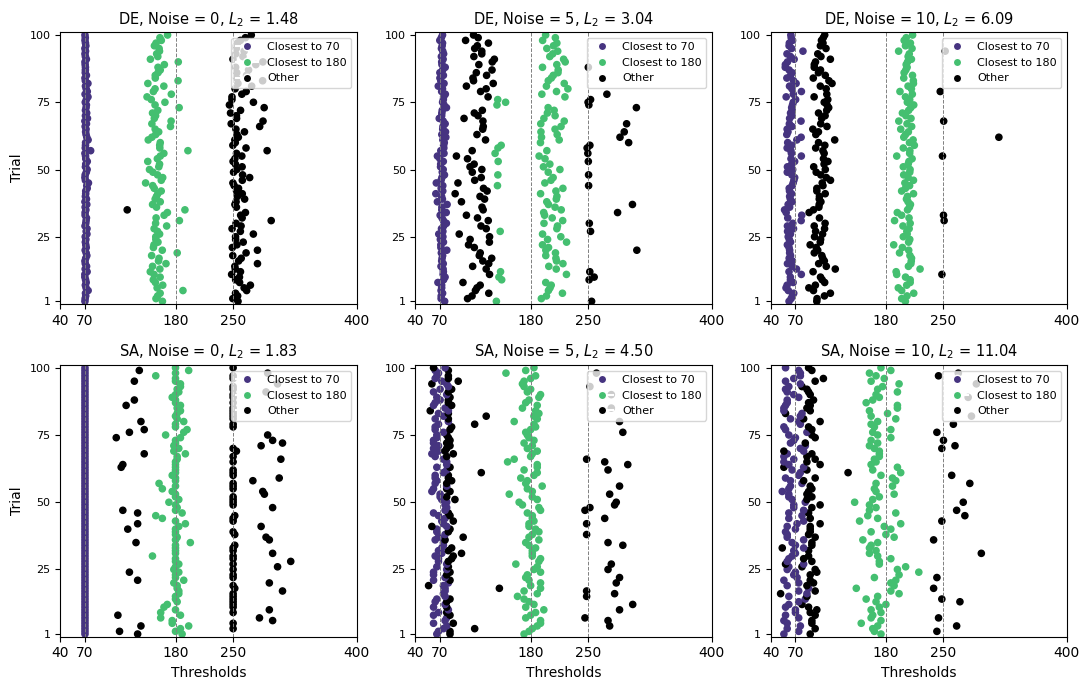

In [5]:
noise_levels = [0, 5, 10]
n = 200

viridis = plt.get_cmap('viridis')
purple_color = viridis(0.15)  # viridis purple value
green_color = viridis(0.7)    # viridis green value

plt.figure(figsize=(11, 7))

methods_name = ['DE', 'SA']  # Methods

for k, method_name in enumerate(methods_name):
    for i, noise in enumerate(noise_levels):
        ax = plt.subplot(2, 3, k * 3 + i + 1)

        # Load data for each method
        if method_name == 'DE':
            with open(f'results/simulation2/de-n{n}K3_noise{noise}_Loss2.pkl', 'rb') as fi:
                res = pickle.load(fi)
            thresholds = np.stack([result[0] for result in res])[:, 1:4]
            loss = np.array([result[1] for result in res])

        elif method_name == 'SA':
            with open(f"results/simulation2/sa-n{n}K2-noise{noise}_Loss2.pkl", 'rb') as f:
                res = pickle.load(f)
            thresholds = np.array([r['thresholds_history'][-2] for r in res])[:, 0, :]
            loss = np.array([r['loss_history'][3] for r in res])

        # Scatter plot for thresholds
        for j in range(thresholds.shape[0]):
            trial = [j + 1] * 3
            color = ['black'] * 3
            blue_idx = np.argmin(np.abs(thresholds[j, :] - 70))
            green_idx = np.argmin(np.abs(thresholds[j, :] - 180))
            color[blue_idx] = purple_color
            color[green_idx] = green_color
            ax.scatter(thresholds[j, :], trial, c=color, s=20)

        # Vertical lines for base  thresholds
        plt.vlines([70, 180, 250], 0, 101, linestyle='--', color='grey', linewidth=0.7)
        
        plt.ylim(0, 101)
        plt.xticks([40, 70, 180, 250, 400])
        plt.yticks([1, 25, 50, 75, 100], fontsize=8)

        # Set title
        title = f"{method_name}, Noise = {noise}"
        if loss is not None:
            title += r", $L_2$ = {:.2f}".format(np.mean(loss))
        plt.title(title, fontsize=10.5)

        # Axis labels
        if k == 1:  # Bottom row
            plt.xlabel('Thresholds')
        if i == 0:  # Left column
            plt.ylabel('Trial')

        # Add legend
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Closest to 70', markerfacecolor=purple_color, markersize=6),
            Line2D([0], [0], marker='o', color='w', label='Closest to 180', markerfacecolor=green_color, markersize=6),
            Line2D([0], [0], marker='o', color='w', label='Other', markerfacecolor='black', markersize=6)
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
# plt.savefig("./images/setting2.jpeg", dpi=600, bbox_inches="tight")
plt.savefig("./images_sim/setting2.tiff", dpi=800, bbox_inches="tight")
plt.show()

In [11]:
# Analysis of seemingly outliers for DE: compared to the loss at the oracle thresholds
oracle = np.array([40, 70, 180, 250, 400])
n = 200
noise_list = [0, 5, 10]

for noise in noise_list:
    with open(f'results/simulation2/de-n{n}K3_noise{noise}_Loss2.pkl', 'rb') as fi:
        res = pickle.load(fi)
    thresholds = np.stack([result[0] for result in res])[:, 1:4]
    losses = np.array([result[1] for result in res])

    # Those seemingly outliers have thresholds above 240
    print(f"Noise {noise}")

    indices = np.where(~np.any((thresholds >= 140) & (thresholds <= 220), axis=1))[0]
    print(f"    Indices of trials with thresholds not close to 180 (not in [140, 220]): {indices}")
    
    for index in indices:
        seed = SEED + index
        data = simul_uniform_mixture(n, setting="Setting2", eps=noise, seed=seed)
        data_class = Distribution(data, M=200)
        data_class.Wdist_matrix()

        # Compare with the losses at the oracle thresholds
        oracle_loss = fitness(oracle[1:4], data_class, loss="Loss2")
        improvement = -(losses[index] - oracle_loss) / oracle_loss * 100
        print(f"\tIndex {index}:", improvement, "% improvement from oracle loss")


Noise 0
    Indices of trials with thresholds not close to 180 (not in [140, 220]): []
Noise 5
    Indices of trials with thresholds not close to 180 (not in [140, 220]): [ 0 10 22 43 55 67 73 75 76 79 81 89 90]
	Index 0: 63.84884135759003 % improvement from oracle loss
	Index 10: 63.72497077178172 % improvement from oracle loss
	Index 22: 73.54316811258363 % improvement from oracle loss
	Index 43: 53.43603708399609 % improvement from oracle loss
	Index 55: 70.76687585784556 % improvement from oracle loss
	Index 67: 71.76784752365778 % improvement from oracle loss
	Index 73: 69.03080459685488 % improvement from oracle loss
	Index 75: 63.55075815468225 % improvement from oracle loss
	Index 76: 64.02358238069489 % improvement from oracle loss
	Index 79: 62.64497031046766 % improvement from oracle loss
	Index 81: 77.77788751621127 % improvement from oracle loss
	Index 89: 64.29488377835582 % improvement from oracle loss
	Index 90: 63.85119761707261 % improvement from oracle loss
Noise 10


In [ ]:
# Analysis of seemingly outliers for DE: compared to the loss at the oracle thresholds
oracle = np.array([40, 70, 180, 250, 400])
n = 200
noise_list = [0, 5, 10]

for noise in noise_list:
    with open(f'results/simulation2/de-n{n}K3_noise{noise}_Loss2.pkl', 'rb') as fi:
        res = pickle.load(fi)
    thresholds = np.stack([result[0] for result in res])[:, 1:4]
    losses = np.array([result[1] for result in res])

    # Those seemingly outliers have thresholds above 240
    print(f"Noise {noise}")

    indices = np.where(thresholds > 240)[0]
    print(f"    Indices of trials with a threshold > 240: {indices}")
    
    for index in indices:
        seed = SEED + index
        data = simul_uniform_mixture(n, setting="Setting2", eps=noise, seed=seed)
        data_class = Distribution(data, M=200)
        data_class.Wdist_matrix()

        # Compare with the losses at the oracle thresholds
        oracle_loss = fitness(oracle[1:4], data_class, loss="Loss2")
        improvement = -(losses[index] - oracle_loss) / oracle_loss * 100
        print(f"\tIndex {index}:", improvement, "% improvement from oracle loss")


Noise 0
    Indices of trials with a threshold > 240: [33 78]
	Index 33: 30.986323783621973 % improvement from oracle loss
	Index 78: 44.33439000101538 % improvement from oracle loss
Noise 5
    Indices of trials with a threshold > 240: [28 31 44 52 57]
	Index 28: 65.7040617592472 % improvement from oracle loss
	Index 31: 54.31192284840377 % improvement from oracle loss
	Index 44: 61.0776802894983 % improvement from oracle loss
	Index 52: 72.2501864192431 % improvement from oracle loss
	Index 57: 67.20197585572971 % improvement from oracle loss
Noise 10
    Indices of trials with a threshold > 240: [ 3 69 78 90 99]
	Index 3: 47.98816998372811 % improvement from oracle loss
	Index 69: 69.46005861059531 % improvement from oracle loss
	Index 78: 54.020485167637176 % improvement from oracle loss
	Index 90: 59.796785766223984 % improvement from oracle loss
	Index 99: 57.90288765594368 % improvement from oracle loss


Supplemental figures

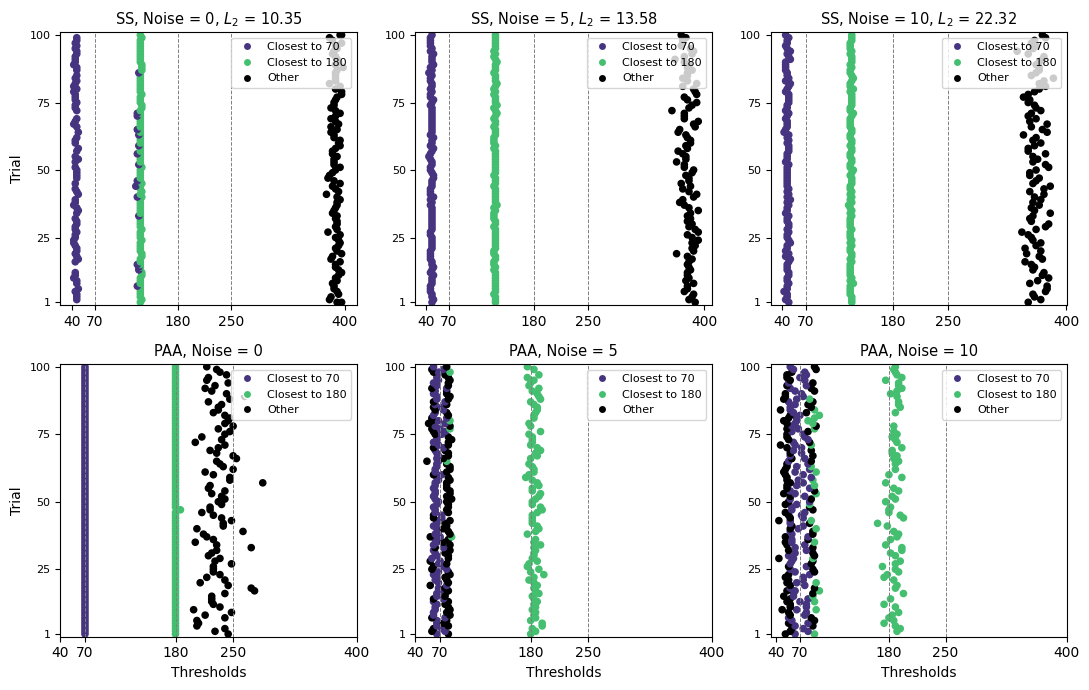

In [ ]:
noise_levels = [0, 5, 10]
n = 200

viridis = plt.get_cmap('viridis')
purple_color = viridis(0.15)  # viridis purple value
green_color = viridis(0.7)    # viridis green value

plt.figure(figsize=(11, 7))

methods_name = ['SS', 'PAA']  # Methods

for k, method_name in enumerate(methods_name):
    for i, noise in enumerate(noise_levels):
        ax = plt.subplot(2, 3, k * 3 + i + 1)

        # Load data for each method
        if method_name == 'SS':
            with open(f"results/simulation2/ss-n{n}-noise{noise}_Loss2.pkl", 'rb') as f:
                res = pickle.load(f)
            thresholds = np.array([r['thresholds_history'] for r in res])
            loss = np.array([r['loss_history'][3] for r in res])

        elif method_name == 'PAA':
            with open(f'results/simulation2/paa-n{n}-noise{noise}.pkl', "rb") as f:
                res = pickle.load(f)
            thresholds = np.array([r['thres_history'][-2] for r in res])
            loss = None  # No loss provided for PAA in your code

        # Scatter plot for thresholds
        for j in range(thresholds.shape[0]):
            trial = [j + 1] * 3
            color = ['black'] * 3
            blue_idx = np.argmin(np.abs(thresholds[j, :] - 70))
            green_idx = np.argmin(np.abs(thresholds[j, :] - 180))
            color[blue_idx] = purple_color
            color[green_idx] = green_color
            ax.scatter(thresholds[j, :], trial, c=color, s=20)

        # Vertical lines for base thresholds
        plt.vlines([70, 180, 250], 0, 101, linestyle='--', color='grey', linewidth=0.7)
        
        plt.ylim(0, 101)
        plt.xticks([40, 70, 180, 250, 400])
        plt.yticks([1, 25, 50, 75, 100], fontsize=8)

        # Set title
        title = f"{method_name}, Noise = {noise}"
        if loss is not None:
            title += r", $L_2$ = {:.2f}".format(np.mean(loss))
        plt.title(title, fontsize=10.5)

        # Axis labels
        if k == 1:  # Bottom row
            plt.xlabel('Thresholds')
        if i == 0:  # Left column
            plt.ylabel('Trial')

        # Add legend
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Closest to 70', markerfacecolor=purple_color, markersize=6),
            Line2D([0], [0], marker='o', color='w', label='Closest to 180', markerfacecolor=green_color, markersize=6),
            Line2D([0], [0], marker='o', color='w', label='Other', markerfacecolor='black', markersize=6)
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
# plt.savefig("./images/setting2-K3.jpeg", dpi=600, bbox_inches="tight")
plt.show()

##### K=2 thresholds

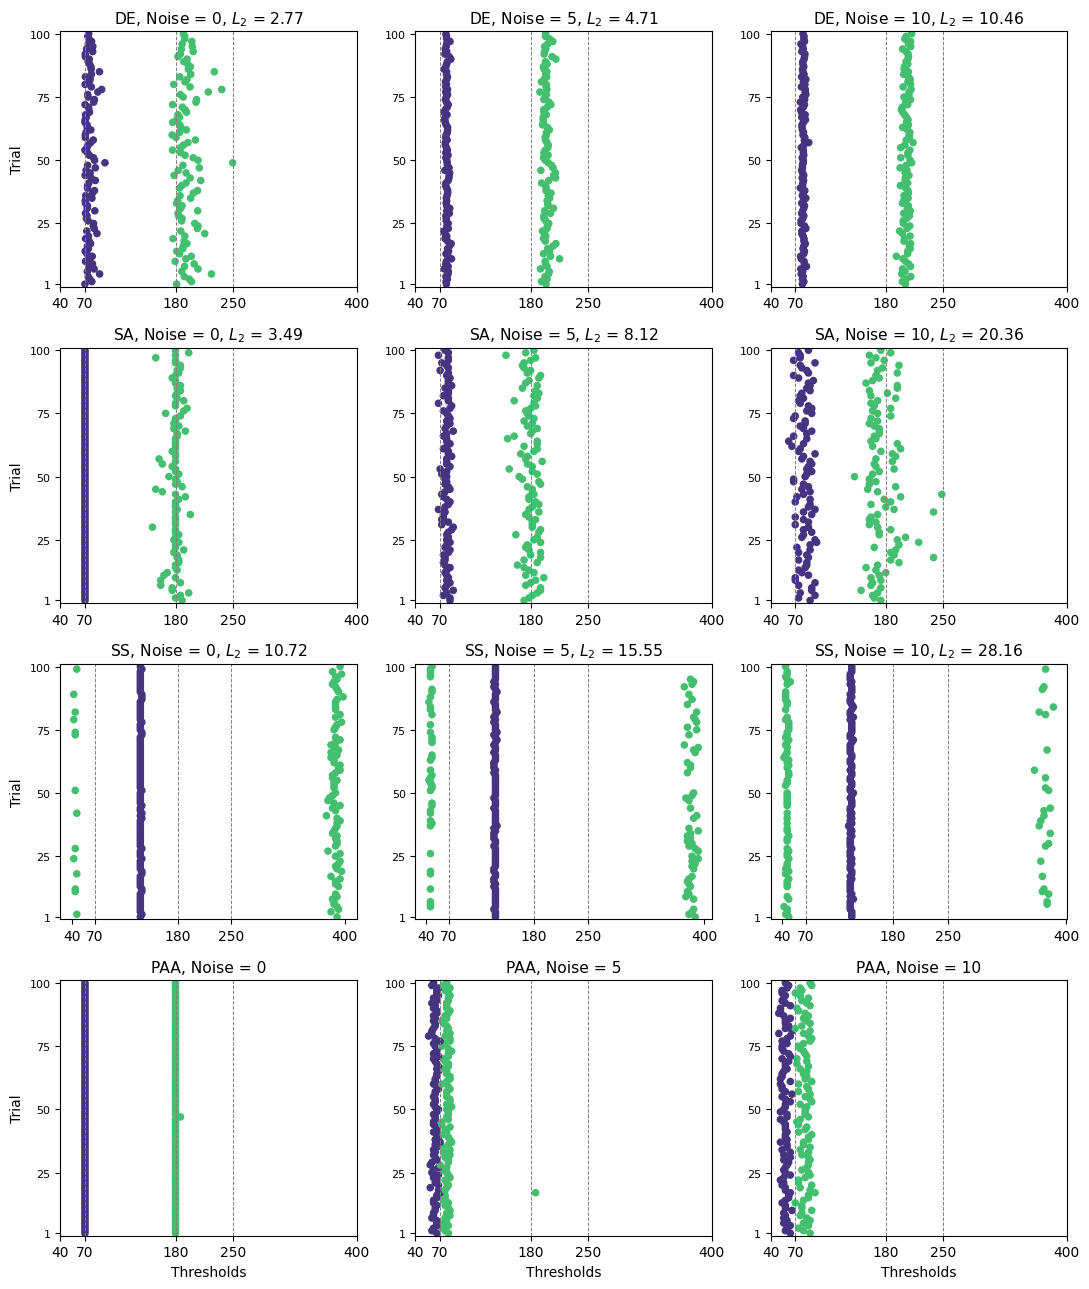

In [ ]:
noise_levels = [0, 5, 10]
n = 200

viridis = plt.get_cmap('viridis')
purple_color = viridis(0.15)  # viridis purple value
green_color = viridis(0.7)    # viridis green value

plt.figure(figsize=(11, 13))

methods_name = ['DE', 'SA', 'SS', 'PAA']  # Methods

for k, method_name in enumerate(methods_name):
    for i, noise in enumerate(noise_levels):
        ax = plt.subplot(4, 3, k * 3 + i + 1)

        # Load data for each method
        if method_name == 'DE':
            with open(f'results/simulation2/de-n{n}K2_noise{noise}_Loss2.pkl', 'rb') as fi:
                res = pickle.load(fi)
            thresholds = np.stack([result[0] for result in res])[:, 1:3]
            loss = np.array([result[1] for result in res])

        elif method_name == 'SA':
            with open(f"results/simulation2/sa-n{n}K2-noise{noise}_Loss2.pkl", 'rb') as f:
                res = pickle.load(f)
            thresholds = np.array([r['thresholds_history'][-1] for r in res])[:, 0, :]
            loss = np.array([r['loss_history'][2] for r in res])

        elif method_name == 'SS':
            with open(f"results/simulation2/ss-n{n}-noise{noise}_Loss2.pkl", 'rb') as f:
                res = pickle.load(f)
            thresholds = np.array([r['thresholds_history'][:2] for r in res])
            loss = np.array([r['loss_history'][2] for r in res])

        elif method_name == 'PAA':
            with open(f'results/simulation2/paa-n{n}-noise{noise}.pkl', "rb") as f:
                res = pickle.load(f)
            thresholds = np.array([r['thres_history'][-1] for r in res])
            loss = None  # No loss provided

        # Scatter plot for thresholds
        for j in range(thresholds.shape[0]):
            trial = [j + 1] * 2
            color = [purple_color, green_color]
            ax.scatter(thresholds[j, :], trial, c=color, s=20)

        # Vertical lines for base thresholds
        plt.vlines([70, 180, 250], 0, 101, linestyle='--', color='grey', linewidth=0.7)
        
        plt.ylim(0, 101)
        plt.xticks([40, 70, 180, 250, 400])
        plt.yticks([1, 25, 50, 75, 100], fontsize=8)

        # Set title
        title = f"{method_name}, Noise = {noise}"
        if loss is not None:
            title += r", $L_2$ = {:.2f}".format(np.mean(loss))
        plt.title(title, fontsize=11.2)

        # Axis labels
        if k == 3:  # Bottom row
            plt.xlabel('Thresholds')
        if i == 0:  # Left column
            plt.ylabel('Trial')

plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.tight_layout()
# plt.savefig("./images/setting2-K2.jpeg", dpi=600, bbox_inches="tight")
plt.show()

## Visualization of simulated data via quantiles

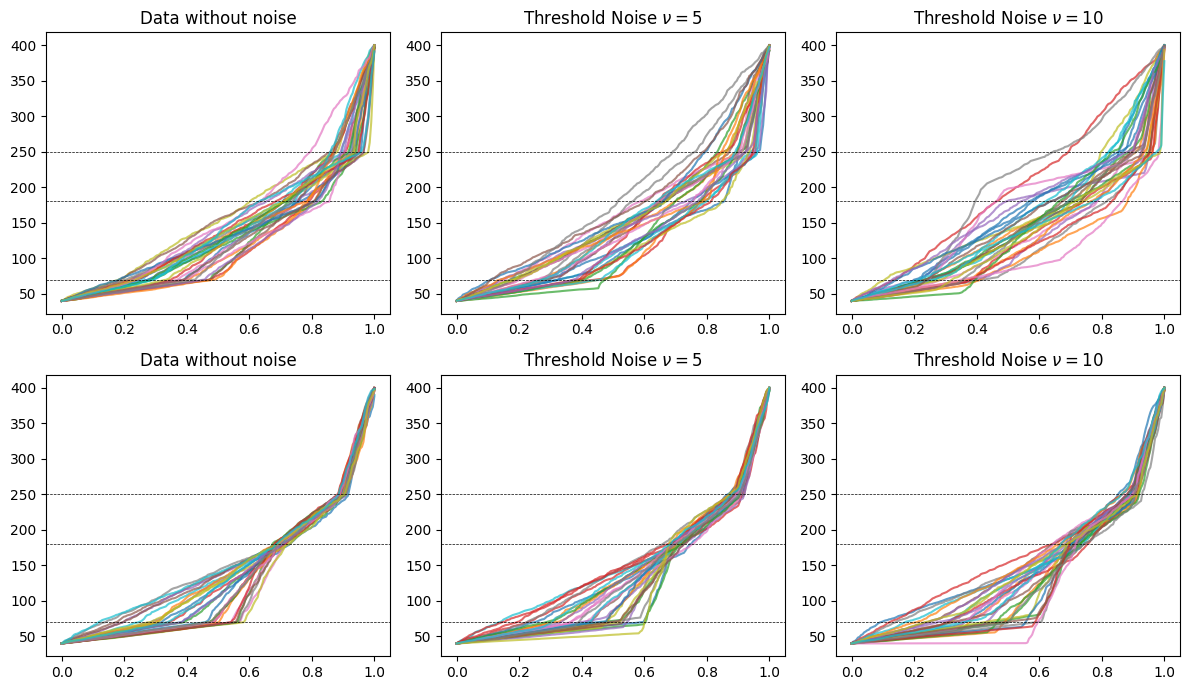

In [ ]:
seed = 42

n = 30
thresholds = (40, 70, 180, 250, 400)
gr = np.linspace(0, 1, 202)  # Grid for quantile calculation
settings = ["Setting1", "Setting2"]

# Data generation for each setting and noise level
data_by_setting = {}
for setting in settings:
    data_by_setting[setting] = {
        "Noiseless": simul_uniform_mixture(n, setting=setting, eps=0, seed=seed),
        "Noise 5": simul_uniform_mixture(n, setting=setting, eps=5, seed=seed),
        "Noise 10": simul_uniform_mixture(n, setting=setting, eps=10, seed=seed),
    }

# Plot setup
plt.figure(figsize=(12, 7))
titles = [
    'Data without noise', r"Threshold Noise $\nu=5$", r"Threshold Noise $\nu=10$",
    'Data without noise', r"Threshold Noise $\nu=5$", r"Threshold Noise $\nu=10$"
]

# Plotting loop
for i, (setting, data_dict) in enumerate(data_by_setting.items()):
    for j, (noise_label, data) in enumerate(data_dict.items()):
        plt.subplot(2, 3, i * 3 + j + 1)

        # Plot quantiles for each dataset
        for k in range(n):
            plt.plot(gr, np.quantile(data[k], gr), alpha=0.7)

        # Add horizontal threshold lines
        for threshold in thresholds[1:-1]:
            plt.axhline(threshold, color='black', linestyle='--', linewidth=0.5)

        # Set subplot title
        plt.title(titles[i * 3 + j])

# Adjust layout and show plot
plt.tight_layout()
# plt.savefig("./images/supp-quantiles.jpeg", dpi=600, bbox_inches='tight')
plt.show()

## Additional simulations with n=50, 100

In [ ]:
from tools.additional_simulations import (
    LOSS_TYPES,
    NOISE_LEVELS,
    SETTING_CONFIGS,
    SUPPORTED_N,
    load_oracle_result,
    result_dir,
)


In [ ]:
# Placeholder for loading additional n=50/100 results and generating tables.
SUPPORTED_N
